<h2 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
0. Import Libraries

</font>
</h2>

In [9]:
import pandas as pd
import numpy

In [10]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

<h3 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
1. Feature Engineering and Pre Processing</font>
</h3>


In [11]:
print("The number of samples into the train data is {}.".format(train.shape[0]))
print("The number of samples into the test data is {}.".format(test.shape[0]))

The number of samples into the train data is 103904.
The number of samples into the test data is 25976.


In [12]:
# remove Unnamed: 0 and id because they are not useful
train = train.drop(['Unnamed: 0', 'id'], axis=1)
test = test.drop(['Unnamed: 0', 'id'], axis=1)

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    1039

In [14]:
# label encode the target variable (satisfaction)
target_to_label = {'neutral or dissatisfied': 0, 'satisfied': 1}
label_to_target = {target_to_label[key]: key for key in target_to_label}

train['satisfaction'] = train['satisfaction'].map(target_to_label)

In [15]:
category_columns = ['Type of Travel', 'Customer Type', 'Class']
for col in category_columns:
    print(train[col].value_counts())
    print('-'*50)

Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64
--------------------------------------------------
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64
--------------------------------------------------
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64
--------------------------------------------------


In [16]:
type_to_label = {'Personal Travel': 0, 'Business travel': 1}
label_to_type = {type_to_label[key]: key for key in type_to_label}
train['Type of Travel'] = train['Type of Travel'].map(type_to_label)
test['Type of Travel'] = test['Type of Travel'].map(type_to_label)

In [17]:
customer_to_label = {'disloyal Customer': 0, 'Loyal Customer': 1}
label_to_customer = {customer_to_label[key]: key for key in customer_to_label}
train['Customer Type'] = train['Customer Type'].map(customer_to_label)
test['Customer Type'] = test['Customer Type'].map(customer_to_label)

In [18]:
# The typical order of a flight class is the following: Eco < Eco Plus < Business
# Economy Class (Eco): The most basic and affordable class
# Economy Plus (Eco Plus): An optional class offered by some airlines. It provides slightly better service than Economy Class (such as more legroom, priority boarding, etc.)
# Business Class: The highest class available, replete with the best service and most expensive tickets

class_to_label = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
label_to_class = {class_to_label[key]: key for key in class_to_label}
train['Class'] = train['Class'].map(class_to_label)
test['Class'] = test['Class'].map(class_to_label)

In [19]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  int64  
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  int64  
 4   Class                              103904 non-null  int64  
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    1039

In [20]:
# we encode Gender using binary encoding because if we use one-hot encoding, we will have two columns which are correlated
gender_to_label = {'Male': 0, 'Female': 1}
label_to_gender = {gender_to_label[key]: key for key in gender_to_label}
train['Gender'] = train['Gender'].map(gender_to_label)
test['Gender'] = test['Gender'].map(gender_to_label)

In [21]:
train.describe()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,...,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000,103904.000000
mean,0.507459,0.817322,39.379706,0.689627,1.028103,1189.448375,2.729683,3.060296,2.756901,2.976883,...,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678,0.433333
std,0.499947,0.386404,15.114964,0.462649,0.962858,997.147281,1.327829,1.525075,1.398929,1.277621,...,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682,0.495538
min,0.000000,0.000000,7.000000,0.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,27.000000,0.000000,0.000000,414.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,40.000000,1.000000,1.000000,843.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,51.000000,1.000000,2.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,1.000000
max,1.000000,1.000000,85.000000,1.000000,2.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000,1.000000


In [22]:
# check if the target variable is balanced
train['satisfaction'].value_counts()

satisfaction
0    58879
1    45025
Name: count, dtype: int64

<h3 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
2. Exploratory Data Analysis (EDA)
</font>
</h3>


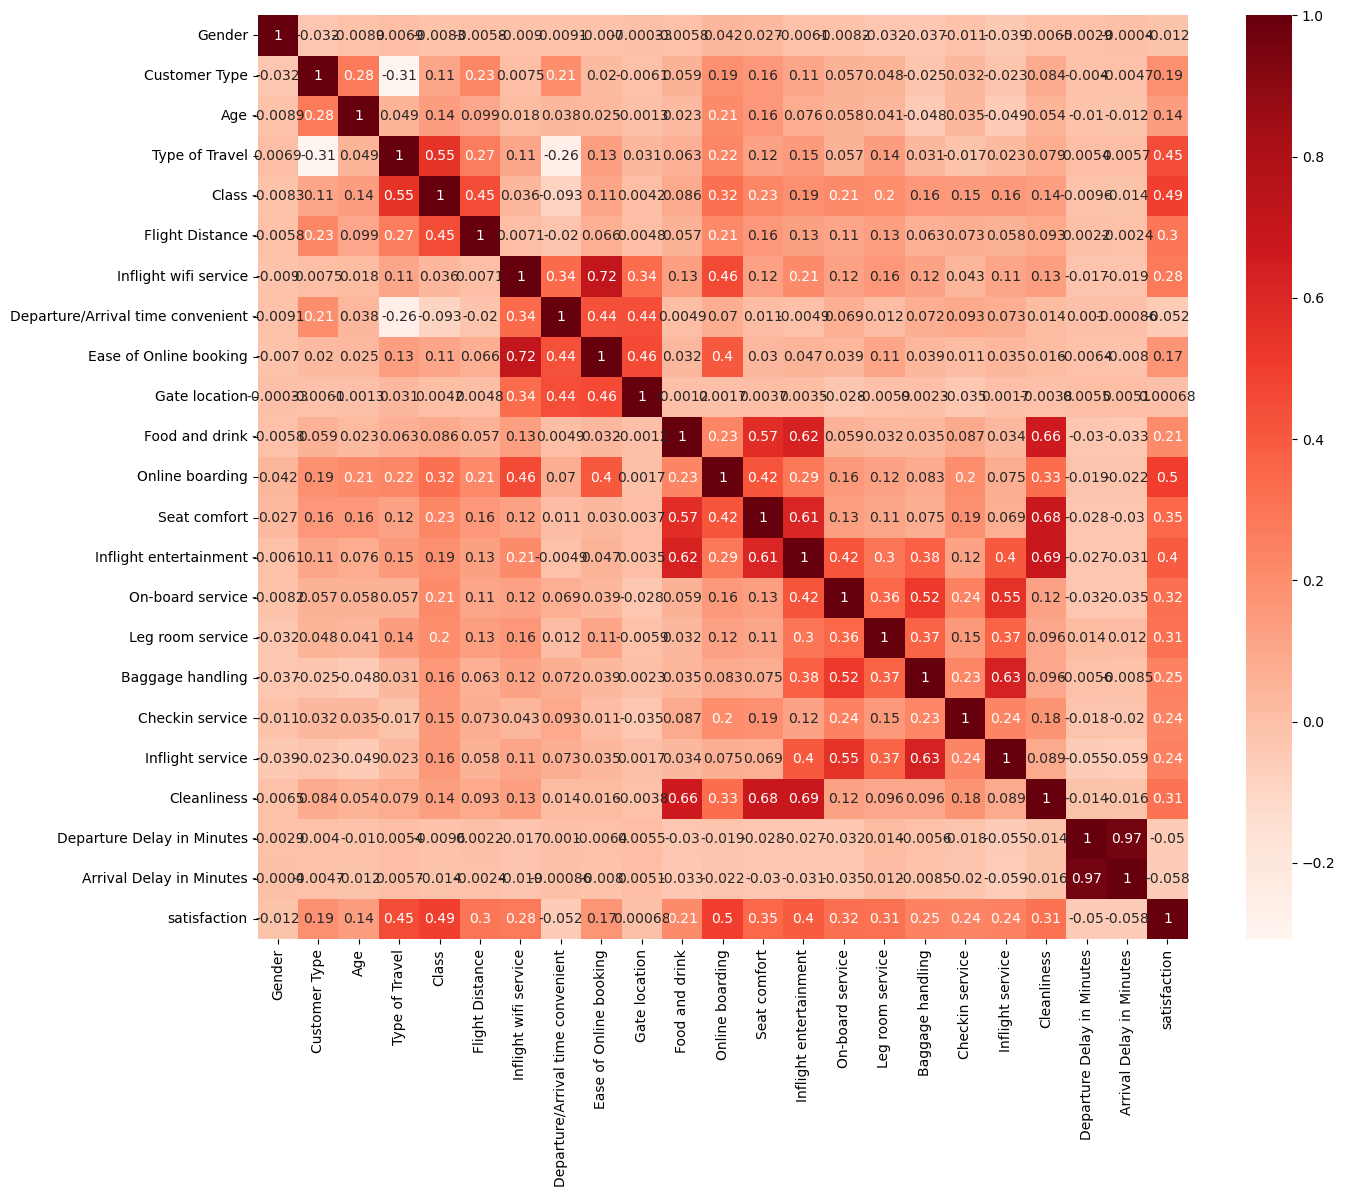

In [23]:
# plot the correlation matrix heatmap
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 12))
cor = train.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

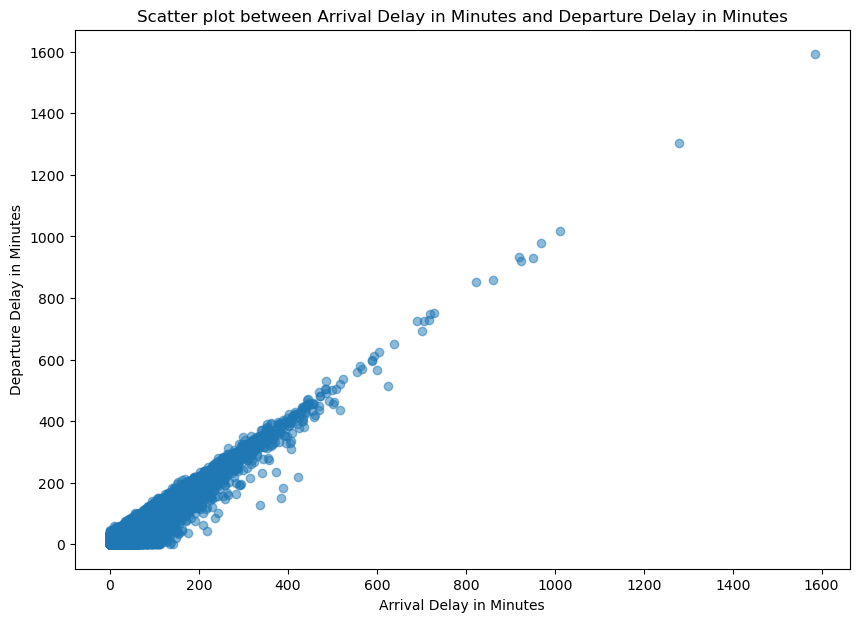

In [24]:
# let's analyze the correlation between Arrival Delay in Minutes and Departure Delay in Minutes using a scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(train['Arrival Delay in Minutes'], train['Departure Delay in Minutes'], alpha=0.5)
plt.title('Scatter plot between Arrival Delay in Minutes and Departure Delay in Minutes')
plt.xlabel('Arrival Delay in Minutes')
plt.ylabel('Departure Delay in Minutes')
plt.show()

In [25]:
# As we can see from the scatter plot, there is a strong linear relationship between Arrival Delay in Minutes and Departure Delay in Minutes
# so, we can drop one of them. Which one should we drop? Let's decide based on the missing values in each column.
# If both columns have missing values, we can first build a regression model to predict the missing values in one column using the other column.
# However, if only one column has missing values, we can drop the column with missing values.

train.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [26]:
# As the Departure Delay in Minutes column has no missing values, we can drop the Arrival Delay in Minutes column
train = train.drop('Arrival Delay in Minutes', axis=1)
test = test.drop('Arrival Delay in Minutes', axis=1)

In [27]:
# check duplicates
train.duplicated().sum()

0

In [28]:
len(train.columns)

22

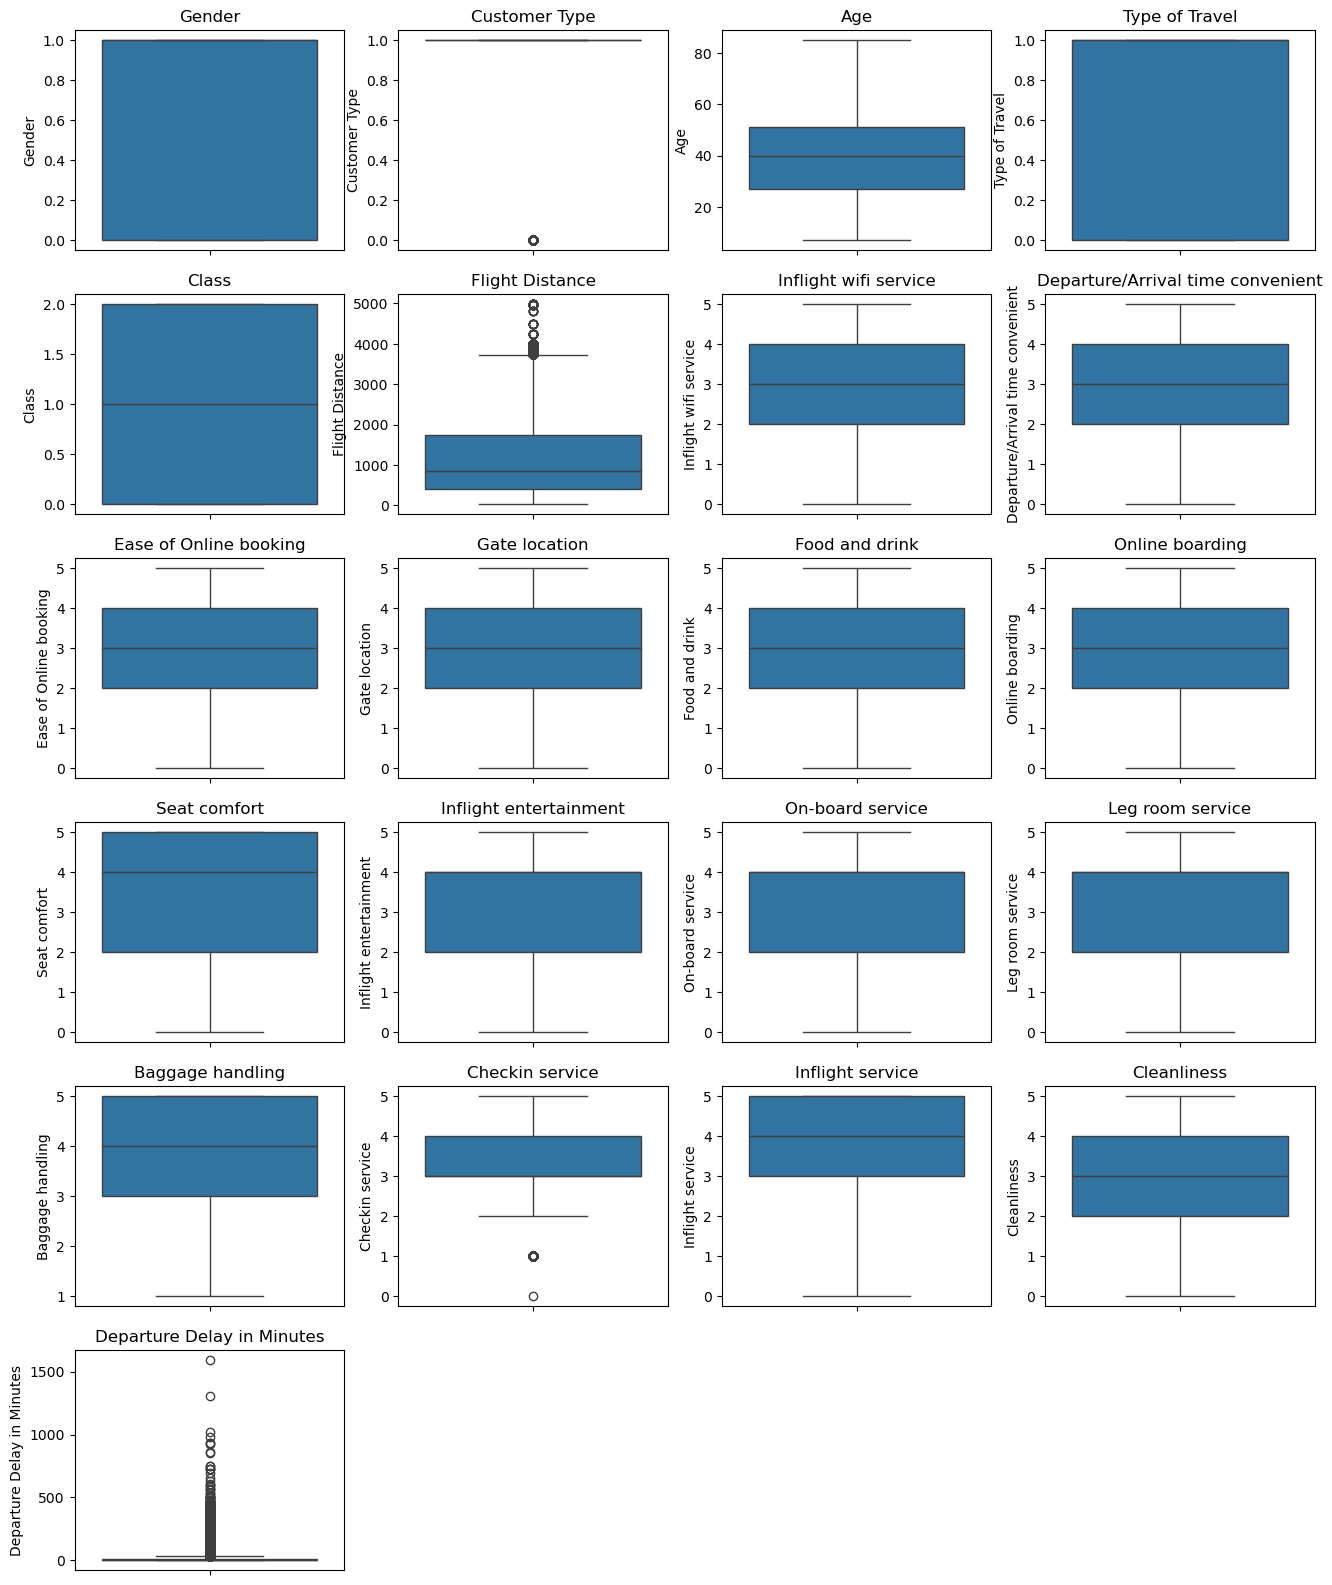

In [29]:
# show box plot for each feature in a single subplot
plt.figure(figsize=(16, 20))
for i, col in enumerate(train.columns):
    if col != 'satisfaction':
        plt.subplot(6, 4, i+1)
        sns.boxplot(train[col])
        plt.title(col)
plt.show()

In [30]:
# find how many outliers are there in each column
for col in train.columns:
    if col != 'satisfaction':
        q1 = train[col].quantile(0.25)
        q3 = train[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        num_outliers = len(train[(train[col] < lower_bound) | (train[col] > upper_bound)])
        print("{} ---> {} outliers [Lower bound: {}, Upper bound: {}]".format(col, num_outliers, lower_bound, upper_bound))

Gender ---> 0 outliers [Lower bound: -1.5, Upper bound: 2.5]
Customer Type ---> 18981 outliers [Lower bound: 1.0, Upper bound: 1.0]
Age ---> 0 outliers [Lower bound: -9.0, Upper bound: 87.0]
Type of Travel ---> 0 outliers [Lower bound: -1.5, Upper bound: 2.5]
Class ---> 0 outliers [Lower bound: -3.0, Upper bound: 5.0]
Flight Distance ---> 2291 outliers [Lower bound: -1579.5, Upper bound: 3736.5]
Inflight wifi service ---> 0 outliers [Lower bound: -1.0, Upper bound: 7.0]
Departure/Arrival time convenient ---> 0 outliers [Lower bound: -1.0, Upper bound: 7.0]
Ease of Online booking ---> 0 outliers [Lower bound: -1.0, Upper bound: 7.0]
Gate location ---> 0 outliers [Lower bound: -1.0, Upper bound: 7.0]
Food and drink ---> 0 outliers [Lower bound: -1.0, Upper bound: 7.0]
Online boarding ---> 0 outliers [Lower bound: -1.0, Upper bound: 7.0]
Seat comfort ---> 0 outliers [Lower bound: -2.5, Upper bound: 9.5]
Inflight entertainment ---> 0 outliers [Lower bound: -1.0, Upper bound: 7.0]
On-board 

In [31]:
# split the data into features and target variable
X = train.drop('satisfaction', axis=1)
y = train['satisfaction']

In [32]:
# split the data into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(test)

<h2  align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
3. Model Development and Training
</font>
</h2>


In [34]:
# baseline model 1: k-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_val)

print("Accuracy of KNN model on validation set: {:.2f}%".format(accuracy_score(y_val, y_pred) * 100))

Accuracy of KNN model on validation set: 92.83%


In [35]:
# baseline model 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

print("Accuracy of Random Forest model on validation set: {:.2f}%".format(accuracy_score(y_val, y_pred) * 100))

Accuracy of Random Forest model on validation set: 96.16%


In [36]:
import keras

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
early_stopping_cb = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy')

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val), batch_size=32,
                    epochs=100, callbacks=[early_stopping_cb])

Epoch 1/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - accuracy: 0.8553 - loss: 0.3308 - val_accuracy: 0.9346 - val_loss: 0.1567
Epoch 2/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9349 - loss: 0.1645 - val_accuracy: 0.9408 - val_loss: 0.1376
Epoch 3/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9441 - loss: 0.1410 - val_accuracy: 0.9475 - val_loss: 0.1272
Epoch 4/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9461 - loss: 0.1316 - val_accuracy: 0.9471 - val_loss: 0.1336
Epoch 5/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.9493 - loss: 0.1224 - val_accuracy: 0.9514 - val_loss: 0.1173
Epoch 6/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - accuracy: 0.9503 - loss: 0.1194 - val_accuracy: 0.9514 - val_loss: 0.1162
Epoch 7/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9525 - loss: 0.1148 - val_accuracy: 0.9527 - val_loss: 0.1123
Epoch 8/100
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9545 

<h2  align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
4. Evaluation
</font>
</h2>



In [37]:
_, accuracy = model.evaluate(X_val, y_val, verbose=0)
print("Accuracy of the model on validation set: {:.2f}%".format(accuracy * 100))

Accuracy of the model on validation set: 96.09%


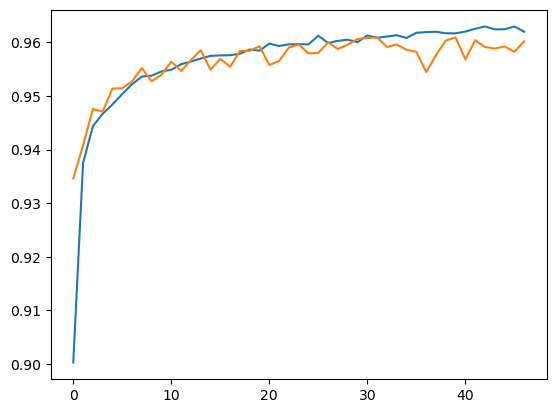

In [41]:
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

<h2  align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
5. Prediction & Submission
</font>
</h2>



In [38]:
test_pred = model.predict(X_test)
test_pred = (test_pred > 0.5).astype(int)

812/812 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [39]:
test_pred = pd.Series(test_pred.reshape(-1)).map(label_to_target)
submission = pd.DataFrame({'satisfaction': test_pred})
submission

,satisfaction
0,neutral or dissatisfied
1,neutral or dissatisfied
2,neutral or dissatisfied
3,satisfied
4,neutral or dissatisfied
...,...
25971,neutral or dissatisfied
25972,satisfied
25973,satisfied
25974,neutral or dissatisfied
